#Data Preprocessing

*My Steps -> Summary*
- Merge: all 3 CSVs
- Keep: useful columns
- Remove: missing values
- Create: sentiment labels
- Clean: review text
- Remove: very short reviews
- Save: final dataset

In [1]:
#Imports

import pandas as pd
from pathlib import Path
import re

###Merging & Reading & Reviewing the CSVs

In [2]:
#Merging the csv data
data_folder = Path("/content")
csv_files = list(data_folder.glob("*.csv"))
csv_files

df_list = []

#reading each CSV safely
for file in csv_files:
    temp_df = pd.read_csv(
        file,
        engine="python",
        on_bad_lines="skip"
    )

    df_list.append(temp_df)

#merging all CSV files into one dataframe
df = pd.concat(df_list, ignore_index=True)

#checking merged dataset size
df.shape

(28408, 27)

In [3]:
#Reviewing data
df = df [[
    "name",
    "reviews.rating",
    "reviews.text"
]]

df.head()

#Removing rows where at least one of the three columns is empty
df = df.dropna(subset=["name", "reviews.rating", "reviews.text"])
df.shape

(28379, 3)

#Converting ratings to integers / creating the sentiments / cleaning the text

In [4]:
#Converting the ratings to integers
df["reviews.rating"] = df["reviews.rating"].astype(int)
df["reviews.rating"].unique()

#Creating sentiment column
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"


df["sentiment"] = df["reviews.rating"].apply(map_sentiment)
df["sentiment"].value_counts()

#Outcome: Many positive reviews. Pretty imbalanced


#Cleaning the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ",text) #remove HTML tags
    text = re.sub(r"[^a-zA-Z0-9\s]", " ",text) # remove special characters, keep letters, numbers, spaces only.
    text = re.sub(r"\s+", " ",text).strip() #remove the extra spaces too

    return text


#applying funciton to every review
df["clean_review"] = df["reviews.text"].apply(clean_text)

#showing original vs cleaned text
df[["reviews.text", "clean_review"]].head()


#showing full text side by side (no truncation)
pd.set_option('display.max_colwidth', None)
df[["reviews.text", "clean_review"]].sample(10)

#removing short reviews like "good", "ok", etc.
df = df[df["clean_review"].str.len() > 10]
df.shape

(27473, 5)

#Plot the special characters before the preprocessing

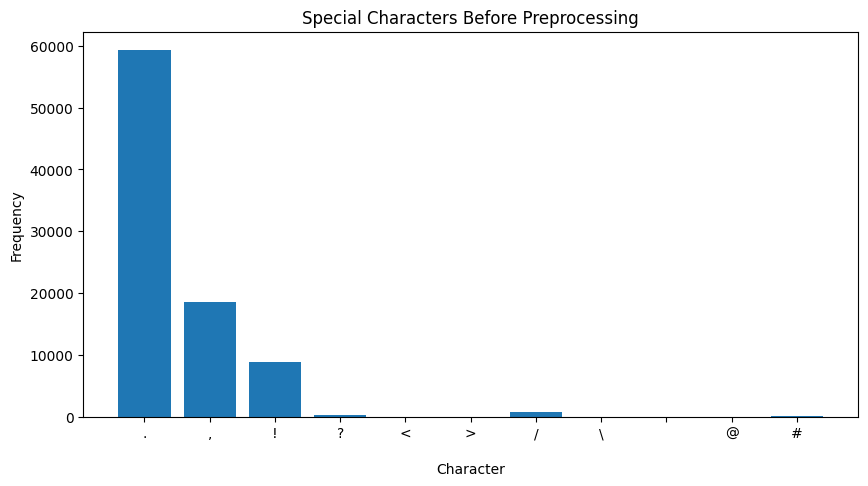

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# combine raw review text
raw_text = " ".join(df["reviews.text"].dropna().astype(str))

# characters to inspect
special_chars = [
    ".", ",", "!", "?", "<", ">",
    "/", "\\", "\n", "@", "#"
]

# count occurrences
char_counts = {
    char: raw_text.count(char)
    for char in special_chars
}

# plot chart
plt.figure(figsize=(10, 5))

plt.bar(
    char_counts.keys(),
    char_counts.values()
)

plt.title("Special Characters Before Preprocessing")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

#Saving the cleaned dataset

In [6]:
#Saving the cleaned dataset

#defining path for cleaned file to be saved to
output_path = Path("/content/outputs/clean_reviews.csv")
output_path.parent.mkdir(exist_ok=True)

#saving the df as a csv
df.to_csv(output_path, index=False)

#printing the condirmation for double-check
print("Saved to:", output_path)

Saved to: /content/outputs/clean_reviews.csv


#Plot the special characters after the preprocessing

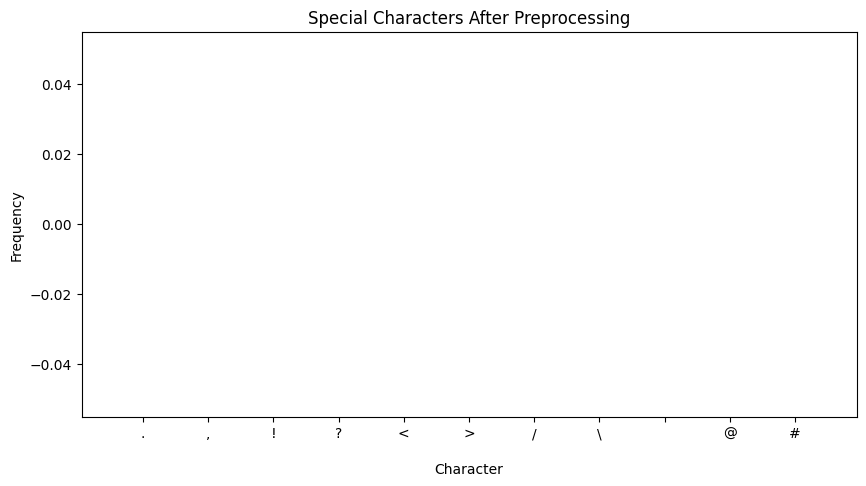

In [7]:
# combine cleaned review text
clean_text = " ".join(df["clean_review"].dropna().astype(str))

# count remaining special characters after preprocessing
clean_char_counts = {
    char: clean_text.count(char)
    for char in special_chars
}

# plot chart
plt.figure(figsize=(10, 5))

plt.bar(
    clean_char_counts.keys(),
    clean_char_counts.values()
)

plt.title("Special Characters After Preprocessing")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()